# VAE + NN Regression
This notebook aims to perform a regression on the production of solar, wind and hydro renewable energy. To achieve this, we are going to use a VAE + NN configuration. The VAE is going to be in charge of reducing the dimensionality of the problem, while the NN will perform the regression itself.

**This notebook runs for one zone and one energy type!** It must be run again to get results relative to a different zone or energy type

## 0: Importing libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
# from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

import optuna
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import json
import os

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit

from datetime import date
import copy

## 1: Import the data
We want to use as features the meteo forecast data that are outputted from notebook 1, while as label the outputs of notebook 2. Is important to **select zone and energy type** here.

In [2]:
# LUCA's IMPORTS
sel_zone = 'IT_NORD'
energies = ['solar','wind','hydro']
detrended_energies = ['detrended_solar','detrended_wind','detrended_hydro']
energy_colors = ['red','green','blue']
target_index = 2

df_features = pd.read_csv(f'1_output/{sel_zone}_meteo_forecast_data.csv')
df_labels = pd.read_csv(f'2_outputs/{sel_zone}_installation_detrended_actuals.csv')

# remove timezone information
df_labels['date_time'] = pd.to_datetime(df_labels['date_time'], utc= True).dt.tz_convert(None)
# sort by date
df_labels = df_labels.sort_values('date_time')
df_labels = df_labels.set_index('date_time')
# resample every 3h with no overlapping windows and keeping the first timestamp as index
start_time = df_labels.index[0]
groups = []
# Define which columns to sum and which to average
sum_columns = ['solar','wind','hydro','load','detrended_solar','detrended_wind','detrended_hydro']
mean_columns = ['ratio','solar_installed','wind_installed','hydro_installed']  # example

groups = []
start_time = df_labels.index[0]

while start_time + pd.Timedelta(hours=3) <= df_labels.index[-1] + pd.Timedelta(minutes=1):
    end_time = start_time + pd.Timedelta(hours=3)
    chunk = df_labels[start_time:end_time - pd.Timedelta(seconds=1)]

    if len(chunk) == 3 and all((chunk.index == [start_time + pd.Timedelta(hours=i) for i in range(3)])):
        summed = chunk[sum_columns].sum()
        averaged = chunk[mean_columns].mean()
        
        combined = pd.concat([summed, averaged])
        combined.name = start_time
        groups.append(combined)

    start_time += pd.Timedelta(hours=3)

# retrieve date time info
result_df = pd.DataFrame(groups).reset_index().rename(columns={'index': 'date_time'})

df_labels = result_df

# normalize time to range [0, 1]
min_time = df_labels['date_time'].min()
max_time = df_labels['date_time'].max()
df_labels['time'] = (df_labels['date_time'] - min_time) / (max_time - min_time)
df_labels['time'] = df_labels['time'].astype(float)  # convert timedelta to float

# keep only desired columns
df_labels = df_labels[['date_time', 'time', 'detrended_solar', 'detrended_wind', 'detrended_hydro']]
df_labels 

,date_time,time,detrended_solar,detrended_wind,detrended_hydro
0,2022-01-01 00:00:00,0.000000,0.000000,0.280479,0.318237
1,2022-01-01 03:00:00,0.000114,0.000000,0.396306,0.325232
2,2022-01-01 06:00:00,0.000228,0.036678,0.219479,0.396564
3,2022-01-01 09:00:00,0.000343,0.278125,0.384061,0.347202
4,2022-01-01 12:00:00,0.000457,0.189566,0.384035,0.341881
...,...,...,...,...,...
8730,2024-12-30 06:00:00,0.999543,0.095458,0.096029,0.550103
8731,2024-12-30 09:00:00,0.999657,0.519010,0.172852,0.344900
8732,2024-12-30 12:00:00,0.999772,0.330239,0.206462,0.339921
8733,2024-12-30 15:00:00,0.999886,0.006103,0.259278,0.669006


In [3]:
df_features

,Unnamed: 0,year_t-8,2t_t-8,solar_t-8,tp_t-8,ws_10m_t-8,ws_100m_t-8,hour_sin_t-8,hour_cos_t-8,day_sin_t-8,...,ws_100m_t-0,hour_sin_t-0,hour_cos_t-0,day_sin_t-0,day_cos_t-0,month_sin_t-0,month_cos_t-0,sin_dayofyear_t-0,cos_dayofyear_t-0,timestamp
0,0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.280164,...,-1.132097,-0.685682,1.408711,0.280448,1.400505,0.702453,1.109234,0.025586,1.291842,2022-01-01 21:00:00
1,1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.280164,...,-0.931334,0.249115,1.890286,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-02 00:00:00
2,2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.280164,...,-0.778698,1.183912,1.408711,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-02 03:00:00
3,3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.280164,...,-0.664870,1.571118,0.246088,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-02 06:00:00
4,4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.280164,...,-0.452988,1.183912,-0.916535,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-02 09:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.287572,...,-1.518295,0.249115,-1.398110,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-31 12:00:00
8316,8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.388240,-0.685682,-0.916535,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-31 15:00:00
8317,8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-31 18:00:00
8318,8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-31 18:00:00


### 1.1: Remove duplicated time information
Here we remove the duplicated time informations, such as day and month (we already have dayoftheyear that represents this same information)

In [4]:
# we use as temporal info the day of the year (1...365)
features = ['day_sin_t-0','day_cos_t-0',
           'day_sin_t-1','day_cos_t-1',
           'day_sin_t-2','day_cos_t-2',
           'day_sin_t-3','day_cos_t-3',
           'day_sin_t-4','day_cos_t-4',
           'day_sin_t-5','day_cos_t-5',
           'day_sin_t-6','day_cos_t-6',
           'day_sin_t-7','day_cos_t-7',
           'day_sin_t-8','day_cos_t-8',
           'month_sin_t-0','month_cos_t-0',
           'month_sin_t-1','month_cos_t-1',
           'month_sin_t-2','month_cos_t-2',
           'month_sin_t-3','month_cos_t-3',
           'month_sin_t-4','month_cos_t-4',
           'month_sin_t-5','month_cos_t-5',
           'month_sin_t-6','month_cos_t-6',
           'month_sin_t-7','month_cos_t-7',
           'month_sin_t-8','month_cos_t-8']

# in alternative one can use the following lines to keep day and month time info
'''
features = ['sin_dayofyear_t0','cos_dayofyear_t0',
            'sin_dayofyear_t1','cos_dayofyear_t1',
            'sin_dayofyear_t2','cos_dayofyear_t2',
            'sin_dayofyear_t3','cos_dayofyear_t3',
            'sin_dayofyear_t4','cos_dayofyear_t4',
            'sin_dayofyear_t5','cos_dayofyear_t5',
            'sin_dayofyear_t6','cos_dayofyear_t6',
            'sin_dayofyear_t7','cos_dayofyear_t7',
            'sin_dayofyear_t8','cos_dayofyear_t8','Unnamed: 0'] '''

df_features = df_features.drop(columns = features)

In [5]:
sel_cols = df_features.columns[1:]
df_features = df_features[sel_cols]
df_features
# methereological data every 3 hours, running over the course of a day  (10 features every 3 hour = 90 features)

,year_t-8,2t_t-8,solar_t-8,tp_t-8,ws_10m_t-8,ws_100m_t-8,hour_sin_t-8,hour_cos_t-8,sin_dayofyear_t-8,cos_dayofyear_t-8,...,2t_t-0,solar_t-0,tp_t-0,ws_10m_t-0,ws_100m_t-0,hour_sin_t-0,hour_cos_t-0,sin_dayofyear_t-0,cos_dayofyear_t-0,timestamp
0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.025562,1.291842,...,-1.279364,-0.785204,-0.539696,-0.982129,-1.132097,-0.685682,1.408711,0.025586,1.291842,2022-01-01 21:00:00
1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.025562,1.291842,...,-1.305169,-0.785204,-0.539696,-0.791966,-0.931334,0.249115,1.890286,0.050415,1.291222,2022-01-02 00:00:00
2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.025562,1.291842,...,-1.369257,-0.785204,-0.539696,-0.709343,-0.778698,1.183912,1.408711,0.050415,1.291222,2022-01-02 03:00:00
3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.025562,1.291842,...,-1.427837,-0.704916,-0.537695,-0.616626,-0.664870,1.571118,0.246088,0.050415,1.291222,2022-01-02 06:00:00
4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.025562,1.291842,...,-1.170501,0.196247,-0.537695,-0.573833,-0.452988,1.183912,-0.916535,0.050415,1.291222,2022-01-02 09:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.024044,1.291843,...,-0.518011,0.586399,-0.545575,-1.441098,-1.518295,0.249115,-1.398110,0.000749,1.292048,2024-12-31 12:00:00
8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-0.567924,-0.485478,-0.545575,-1.249467,-1.388240,-0.685682,-0.916535,0.000749,1.292048,2024-12-31 15:00:00
8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-31 18:00:00
8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-31 18:00:00


In [6]:
df_labels

,date_time,time,detrended_solar,detrended_wind,detrended_hydro
0,2022-01-01 00:00:00,0.000000,0.000000,0.280479,0.318237
1,2022-01-01 03:00:00,0.000114,0.000000,0.396306,0.325232
2,2022-01-01 06:00:00,0.000228,0.036678,0.219479,0.396564
3,2022-01-01 09:00:00,0.000343,0.278125,0.384061,0.347202
4,2022-01-01 12:00:00,0.000457,0.189566,0.384035,0.341881
...,...,...,...,...,...
8730,2024-12-30 06:00:00,0.999543,0.095458,0.096029,0.550103
8731,2024-12-30 09:00:00,0.999657,0.519010,0.172852,0.344900
8732,2024-12-30 12:00:00,0.999772,0.330239,0.206462,0.339921
8733,2024-12-30 15:00:00,0.999886,0.006103,0.259278,0.669006


### 1.2: Joining dataframes
Since some data was discarded in previous notebooks (presence of outliers), we need to ensure that features and labels are aligned over the time information. For this reason, we perform a inner join over the dataframes, ensuring consistency over features and labels.

In [7]:
# keeping only the ones in common
df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_features['date_time'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)
common = pd.merge(df_features, df_labels, on='date_time', how = 'inner')
df_labels = common[df_labels.columns]
df_features = common[df_features.columns]
print(np.shape(df_features),np.shape(df_labels))


(8288, 92) (8288, 5)


/tmp/ipykernel_2821157/2463686259.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)


### 1.3: Setting up Training and Test data
Since our aim is to make our model being able to predict future data from past data, we are going to split training and test set according to time index: the first 80% of our data points will represent our training set, the rest validation set. Computation times are already long for our implementation, so we will avoid K-Folds such as time-rollings

In [8]:
X_array = df_features.drop(columns=['timestamp','date_time']).values # 24h windows
# pick the right label
Y_array = df_labels[detrended_energies[target_index]].values
print(f'Attempting the regression on {detrended_energies[target_index]}')

n_samples = len(X_array)
split_idx = int(n_samples * 0.8)


X_train = X_array[:split_idx]
X_test = X_array[split_idx:] # we do not randomly split into training and test set to avoid replicating data across both (it's a time-series with sliding windows)

Y_train = Y_array[:split_idx]
Y_test = Y_array[split_idx:]

# keep track of the original indices and timestamps
idx_train = df_features.index[:split_idx] # to retrieve date/time at test time (for predictions)
idx_test = df_features.index[split_idx:]

test_timestamps = df_features.loc[idx_test, 'timestamp'].reset_index(drop=True)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

# create a DataLoader for batching (training and test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Reshape the Y tensors (model consistency if we want multiple features)
Y_train_tensor = Y_train_tensor.view(-1, 1)
Y_test_tensor = Y_test_tensor.view(-1, 1)


Attempting the regression on detrended_hydro


### 1.4: Make directories to save screenshots and models

In [9]:
#### make directory for saving screenshots
base_dir = "4_plots"
zone_dir = os.path.join(base_dir, sel_zone)

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}'.")
except Exception as e:
    print(f"An error occurred: {e}")


#### make directory for saving screenshots
base_dir = "4_plots"
zone_dir = os.path.join(base_dir, sel_zone, energies[target_index])

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}'.")
except Exception as e:
    print(f"An error occurred: {e}")

# make directory for saving weights
base_dir = "4_weights"
zone_dir = os.path.join(base_dir, sel_zone, energies[target_index])

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}/{energies[target_index]}'.")
except Exception as e:
    print(f"An error occurred: {e}")

# make directory for saving studies
base_dir = "4_optuna"
zone_dir = os.path.join(base_dir, sel_zone, energies[target_index])

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}/{energies[target_index]}'.")
except Exception as e:
    print(f"An error occurred: {e}")

# make directory for saving BEST MODELS
base_dir = "4_best_models"
zone_dir = os.path.join(base_dir, sel_zone, energies[target_index])

try:
    os.makedirs(zone_dir, exist_ok=True)
    print(f"Directory '{zone_dir}' is ready.")
except PermissionError:
    print(f"Permission denied: Unable to create '{zone_dir}/{energies[target_index]}'.")
except Exception as e:
    print(f"An error occurred: {e}")

Directory '4_plots/IT_NORD' is ready.
Directory '4_plots/IT_NORD/hydro' is ready.
Directory '4_weights/IT_NORD/hydro' is ready.
Directory '4_optuna/IT_NORD/hydro' is ready.
Directory '4_best_models/IT_NORD/hydro' is ready.


## 2: Setup the model and Training
### 2.1: Model definition
Our architecture is composed by a VAE and a NN. The VAE is trained on meteo forecast data, the NN is trained on latent space vectors coming from the VAE and its goal is to perform a regression over detrended production data. We set up the arcitecture by first defining VAE and NN structures separately, then joining them in a combined structure with a common loss function

In [10]:

class VAE(nn.Module): # VAE inherits from nn.Module, base class for neural network modules in PyTorch.
    def __init__(self, input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, activation):
        super(VAE, self).__init__() # to call init method on the parent class of VAE (nn.Module) so that is has all the same functions

        # encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim1) # hidden_dim: hidden layer neurons of encoder NN
        self.fc2 = nn.Linear(hidden_dim1,hidden_dim2)
        self.fc_mu = nn.Linear(hidden_dim2, latent_dim) # latent_dim : output layer neurons of encoder NN
        self.fc_logvar = nn.Linear(hidden_dim2, latent_dim)

        # decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim3)
        self.fc4 = nn.Linear(hidden_dim3, input_dim)
        self.activation = activation

    def encode(self, x):
        #h1 = self.activation(self.batch1(self.fc1(x)))
        h1 = self.activation((self.fc1(x)))
        h2= self.activation(self.fc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)

    def reparameterize(self, mu, logvar): # reparametrization trick to allow backpropagation
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        #h = self.activation(self.batch2(self.fc2(z)))
        h3 = self.activation((self.fc3(z)))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z  # z are the latent representations of the input x


# VAE loss function (separate function, not class method)
def vae_loss(recon_x, x, mu, logvar):
        MSE = F.mse_loss(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return MSE + KLD, MSE, KLD



class Net(nn.Module):
    def __init__(self,Ni,N1,N2,No,activation): # Ni is the dimension of z, N1 the number of hidden neurons of the first layer, N2 the number of hidden neurons of the second layer
        super(Net,self).__init__()

        self.fc1 = nn.Linear(Ni,N1)
        self.batch1 =  nn.BatchNorm1d(N1)
        self.drop1 = nn.Dropout(p=0.1)
        
        self.fc2 = nn.Linear(N1,N2)
        self.batch2 =  nn.BatchNorm1d(N2)
        self.drop2 = nn.Dropout(p=0.1)

        # self.fc3 = nn.Linear(N2, N3)
        # self.batch3 = nn.BatchNorm1d(N3)
        # self.drop3 = nn.Dropout(p=0.1)
        
        self.out = nn.Linear(N2,No)
        self.act = activation


    def forward(self,z): # input from latent variables
            h1 = self.drop1(self.act(self.batch1(self.fc1(z))))
            h2 = self.drop2(self.act(self.batch2(self.fc2(h1))))
        
            #h1= self.act((self.fc1(z)))
            #h2 = self.act((self.fc2(h1)))
            #h3 = self.drop3(self.act(self.batch3(self.fc3(h2))))
            out = F.relu(self.out(h2))
            return (out)


    def regr_loss(self,y,output,lambda_tik):
        mse = F.mse_loss(output, y,reduction='sum')

        w_norm = 0.0
        for param in self.parameters():
            w_norm += torch.sum(torch.abs(param))

        return mse + lambda_tik*w_norm**2




# here we define the full network architecture for VAE+regression

class VAE_Regression(nn.Module):
    def __init__(self,input_dim, hidden_dim1,hidden_dim2,latent_dim,hidden_dim3,vae_activation,N1,N2,No,activation,lambda_tik):
        super(VAE_Regression,self).__init__()

        self.vae = VAE(input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, vae_activation)
        self.regression = Net(latent_dim,N1,N2,No,activation)
        
    def forward(self,x):
        reconstructed_x, mu, logvar, z = self.vae(x) # self.vae(x) is equivalent to calling self.vae.forward(x) thanks to nn.Module
        regr_output = self.regression(mu)
        return (regr_output,reconstructed_x, mu, logvar,z)

    def VAE_loss(self,reconstructed_x, x, mu, logvar): # here VAE_loss/regression_loss are methods of the VAE_Regression class to be accessed later
        return(vae_loss(reconstructed_x, x, mu, logvar))

    def regression_loss(self,y,regr_output,lambda_tik):
        return(self.regression.regr_loss(y,regr_output,lambda_tik))


### 2.2: Grid search on hyperparameters space
The aim of the following cells is to run a grid search on hyperparameters space. The only free parameter (here arbitrarily set up, according to qualitative loss trends) is $\beta$, which rescales VAE loss to be (as far as possible) comparable with regression loss. This way the machine should be able to weigh correctly the two contributes and train the VAE in the best way to perform the regression.

In [11]:
beeta = 1. / 2000
# here we perform a grid search to look for the best hyperparameters: we choose to use 4 folds. We fix as objective to minimize the average validation error over the folds
# To compute each loss estimation before udating the weights, we perform 100 evaluations of the predicted outputs and consider their average as prediction

def get_activation(name):
    return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()
    }[name]

def objective(trial):

    save_dir = "4_weights_VAE_Regression/Single_hydro"
    os.makedirs(save_dir, exist_ok=True)
   
    hidden_dim1 = trial.suggest_categorical("hidden_dim1", [64,128,256]) # previous range 64-256
    hidden_dim2 = trial.suggest_categorical("hidden_dim2", [64,128,256]) #  previous range 64-256
    latent_dim = trial.suggest_categorical("latent_dim", [12,14,16,18,20]) # previous range 6-20
    hidden_dim3 = trial.suggest_categorical("hidden_dim3",[128,256] )  # previous range 64-256

    N1 = trial.suggest_categorical("N1", [64,128,256]) # previous range 16-256
    N2 = trial.suggest_categorical("N2", [64,128,256])

    lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6,1e-4, log=True)
    lr = trial.suggest_float("lr",1e-5,5*1e-4, log=True)
    act_name = trial.suggest_categorical("activation", ["relu"]) # previous searches also with sigmoid and leaky relu 
    activation_fn = get_activation(act_name)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 300
    batch_size = 16
    beta = beeta
    num_folds = 2
    patience= 35
    tscv = TimeSeriesSplit(n_splits=num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)
    fold_last10_regr_losses = []
    fold_model_paths = []


    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)

        #vae_act = get_activation("relu")

        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            # hidden_dim1=vae_best_params["H_DIM"],
            # latent_dim=vae_best_params["Z_DIM"],
            # hidden_dim2=vae_best_params["H_DIM"],
            hidden_dim1=hidden_dim1,
            hidden_dim2=hidden_dim2,
            latent_dim=latent_dim,
            hidden_dim3=hidden_dim3,
            vae_activation= activation_fn,
            N1=N1,
            N2=N2,
            No=Y_train_fold.shape[1],
            activation=activation_fn,
            lambda_tik=lambda_tik
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.25,       # wait 20 epochs of no improvement after which shrink LR by half
            patience=20)      

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

        val_regr_loss_per_epoch = []
        best_val_regr = float('inf')
        early_stop_counter = 0
        best_model_state = None

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1 - beta) * regr_loss + beta * vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - beta) * regr_loss + beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            val_regr_loss_per_epoch.append(val_regr_loss_epoch)

            epoch_train_losses[epoch] += train_loss_epoch / num_folds
            epoch_val_losses[epoch] += val_loss_epoch / num_folds
            epoch_val_vae_losses[epoch] += val_vae_loss_epoch / num_folds
            epoch_val_regr_losses[epoch] += val_regr_loss_epoch / num_folds

            print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_regr_loss_epoch < best_val_regr: # early stopping: stop if val regr loss does not imporve for 20 epoxhs
                best_val_regr = val_regr_loss_epoch
                early_stop_counter = 0
                best_model_state = model.state_dict()
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} for fold {fold+1}")
                break

        # save best model state for this fold
        fold_model_path = f"4_weights/{sel_zone}/{energies[target_index]}/model_trial_{trial.number}_fold_{fold}.pt"
        torch.save(best_model_state, fold_model_path)
        fold_model_paths.append(fold_model_path)

        # average last 10 epochs val regression loss for fold
        fold_avg_regr_last10 = np.mean(val_regr_loss_per_epoch[-10:])
        fold_last10_regr_losses.append(fold_avg_regr_last10)

    # save paths of all fold models in trial attributes
    trial.set_user_attr("fold_model_paths", fold_model_paths)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    # return average regression loss across folds (last 10 epochs)
    return np.mean(fold_last10_regr_losses)

This cell runs the above study. It can be skipped if the study was already ran and it's only needed to load it.

In [12]:
# get current day and month
day = date.today().day
month_name = date.today().strftime("%B")

#study = optuna.create_study(study_name= f"{energies[target_index]}_study_{day}_{month_name}", direction="minimize",
study = optuna.create_study(study_name= f"{sel_zone}_{energies[target_index]}_study", direction="minimize",
    storage=f"sqlite:///{sel_zone}_{energies[target_index]}_optuna.db",
    load_if_exists=True,pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=125))

from tqdm import tqdm
n_trials = 50
study.optimize(objective, n_trials=n_trials,n_jobs=8,catch=(Exception,))

[I 2025-07-05 09:30:06,693] Using an existing study with name 'IT_NORD_hydro_study' instead of creating a new one.


Fold 1 Epoch [1/300] - Total val loss: 5.2958, VAE: 694.5094, Regr: 4.9511
Fold 1 Epoch [1/300] - Total val loss: 7.6802, VAE: 690.0929, Regr: 7.3388
Fold 1 Epoch [1/300] - Total val loss: 15.4012, VAE: 689.5793, Regr: 15.0640
Fold 1 Epoch [1/300] - Total val loss: 9.7170, VAE: 815.1631, Regr: 9.3141
Fold 1 Epoch [1/300] - Total val loss: 5.4473, VAE: 682.2578, Regr: 5.1087
Fold 1 Epoch [1/300] - Total val loss: 29.4268, VAE: 680.7252, Regr: 29.1010
Fold 1 Epoch [1/300] - Total val loss: 22.8823, VAE: 692.1704, Regr: 22.5475
Fold 1 Epoch [1/300] - Total val loss: 32.4400, VAE: 696.7981, Regr: 32.1077
Fold 1 Epoch [2/300] - Total val loss: 5.2550, VAE: 689.4147, Regr: 4.9128
Fold 1 Epoch [2/300] - Total val loss: 7.0698, VAE: 734.8044, Regr: 6.7058
Fold 1 Epoch [2/300] - Total val loss: 14.5250, VAE: 680.1629, Regr: 14.1920
Fold 1 Epoch [2/300] - Total val loss: 7.2110, VAE: 811.4249, Regr: 6.8087
Fold 1 Epoch [2/300] - Total val loss: 4.7975, VAE: 721.9199, Regr: 4.4387
Fold 1 Epoch [2

[I 2025-07-05 10:15:12,015] Trial 40 finished with value: 8.541962849899479 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 64, 'latent_dim': 14, 'hidden_dim3': 256, 'N1': 64, 'N2': 128, 'lambda_tik': 8.008215800187965e-06, 'lr': 0.000107047735712827, 'activation': 'relu'}. Best is trial 40 with value: 8.541962849899479.


Fold 2 Epoch [69/300] - Total val loss: 10.0783, VAE: 442.0717, Regr: 9.8622
Early stopping at epoch 69 for fold 2
Fold 1 Epoch [178/300] - Total val loss: 4.7577, VAE: 730.8967, Regr: 4.3944
Fold 1 Epoch [190/300] - Total val loss: 3.1751, VAE: 672.2268, Regr: 2.8404
Fold 1 Epoch [187/300] - Total val loss: 4.6848, VAE: 698.4017, Regr: 4.3378
Fold 2 Epoch [47/300] - Total val loss: 6.2134, VAE: 840.7230, Regr: 5.7959
Fold 1 Epoch [194/300] - Total val loss: 3.0480, VAE: 723.2583, Regr: 2.6878
Fold 1 Epoch [179/300] - Total val loss: 4.8440, VAE: 730.3746, Regr: 4.4811
Fold 2 Epoch [66/300] - Total val loss: 7.9572, VAE: 921.8080, Regr: 7.5001
Fold 1 Epoch [191/300] - Total val loss: 3.0155, VAE: 672.1648, Regr: 2.6807
Fold 1 Epoch [188/300] - Total val loss: 4.8659, VAE: 700.1788, Regr: 4.5181
Fold 2 Epoch [59/300] - Total val loss: 4.4242, VAE: 651.4222, Regr: 4.1005
Fold 1 Epoch [195/300] - Total val loss: 3.0509, VAE: 722.1643, Regr: 2.6912
Fold 1 Epoch [180/300] - Total val loss: 

[I 2025-07-05 10:16:20,662] Trial 38 finished with value: 5.168975786724384 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 128, 'N1': 128, 'N2': 128, 'lambda_tik': 7.591129628257254e-05, 'lr': 0.0002402923755814902, 'activation': 'relu'}. Best is trial 38 with value: 5.168975786724384.


...

Fold 2 Epoch [109/300] - Total val loss: 10.6775, VAE: 1529.5541, Regr: 9.9177
Early stopping at epoch 109 for fold 2
Fold 2 Epoch [146/300] - Total val loss: 7.2319, VAE: 1575.8489, Regr: 6.4472
Fold 2 Epoch [96/300] - Total val loss: 13.1020, VAE: 1587.1697, Regr: 12.3145
Fold 2 Epoch [147/300] - Total val loss: 6.7907, VAE: 1577.6875, Regr: 6.0049
Fold 2 Epoch [97/300] - Total val loss: 13.5125, VAE: 1588.9625, Regr: 12.7244
Fold 2 Epoch [148/300] - Total val loss: 6.7070, VAE: 1575.5605, Regr: 5.9222
Fold 2 Epoch [98/300] - Total val loss: 13.1577, VAE: 1588.2521, Regr: 12.3698
Fold 2 Epoch [149/300] - Total val loss: 6.6871, VAE: 1575.7131, Regr: 5.9022
Fold 2 Epoch [99/300] - Total val loss: 12.7049, VAE: 1590.4534, Regr: 11.9156
Fold 2 Epoch [150/300] - Total val loss: 6.6002, VAE: 1575.9653, Regr: 5.8152
Fold 2 Epoch [151/300] - Total val loss: 6.5893, VAE: 1576.7588, Regr: 5.8038
Fold 2 Epoch [100/300] - Total val loss: 13.7225, VAE: 1588.7211, Regr: 12.9346
Fold 2 Epoch [152/

[I 2025-07-05 10:59:15,722] Trial 37 finished with value: 11.198610469223798 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 128, 'N1': 128, 'N2': 128, 'lambda_tik': 2.2305465409449817e-05, 'lr': 1.1805769920479362e-05, 'activation': 'relu'}. Best is trial 35 with value: 4.588741661818779.


Fold 2 Epoch [201/300] - Total val loss: 13.0502, VAE: 1562.3570, Regr: 12.2752
Early stopping at epoch 201 for fold 2
Fold 2 Epoch [277/300] - Total val loss: 3.2486, VAE: 840.9682, Regr: 2.8295
Fold 2 Epoch [278/300] - Total val loss: 3.2549, VAE: 839.2024, Regr: 2.8368
Fold 2 Epoch [279/300] - Total val loss: 3.3820, VAE: 843.2039, Regr: 2.9618


[I 2025-07-05 10:59:23,524] Trial 36 finished with value: 5.485193265348242 and parameters: {'hidden_dim1': 128, 'hidden_dim2': 64, 'latent_dim': 12, 'hidden_dim3': 128, 'N1': 128, 'N2': 64, 'lambda_tik': 9.339324976084127e-06, 'lr': 1.1705508470870491e-05, 'activation': 'relu'}. Best is trial 35 with value: 4.588741661818779.


Fold 2 Epoch [280/300] - Total val loss: 3.4279, VAE: 840.8015, Regr: 3.0090
Early stopping at epoch 280 for fold 2


## 3: Loading the best model and plot logic
Assuming the above code has run, a study is available for plotting. Here we want to check the results

In [13]:
# load the study (mind that the code takes the current day and month: change 'em freely!)
day = 3 #date.today().day
month_name = "July" #date.today().strftime("%B")

study = optuna.load_study(
    study_name= f"{sel_zone}_{energies[target_index]}_study",
    storage=f"sqlite:///{sel_zone}_{energies[target_index]}_optuna.db"
)

best_trial= study.best_trial
best_params= best_trial.params

best_params

{'hidden_dim1': 64,
 'hidden_dim2': 64,
 'latent_dim': 14,
 'hidden_dim3': 256,
 'N1': 256,
 'N2': 128,
 'lambda_tik': 5.084849124364813e-06,
 'lr': 0.00030686757283348247,
 'activation': 'relu'}

### 3.1: Saving the best model

In [14]:

# get its best hyperparameters
best_activation = get_activation(best_params["activation"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fold_paths = best_trial.user_attrs["fold_model_paths"]

best_model = VAE_Regression(
            input_dim= X_train.shape[1],
            hidden_dim1=best_params['hidden_dim1'],
            hidden_dim2=best_params['hidden_dim2'],
            latent_dim=best_params['latent_dim'],
            hidden_dim3=best_params['hidden_dim3'],
            vae_activation= best_activation,
            N1=best_params['N1'],
            N2=best_params['N2'],
            No= Y_test_tensor.shape[1],
            activation= best_activation,
            lambda_tik=best_params['lambda_tik']
        ).to(device)

# load the weights of the best trial
best_model.load_state_dict(torch.load(fold_paths[0], map_location=device))


trial=1
trial += 1
# saves current hyperparamters and weights (which you just loaded) into a new file
with open(f"4_best_models/{sel_zone}/{energies[target_index]}/best_model.json", "w") as f:
    json.dump(best_params, f)

torch.save(best_model.state_dict(), f"best_model_{energies[target_index]}_{day}_{month_name}_trial_{trial}.pt")



### 3.2: Preliminary plots
Plots of this section are not definitive: what we want here is to get an idea of the losses' trends and how the model is performing with a general tuning

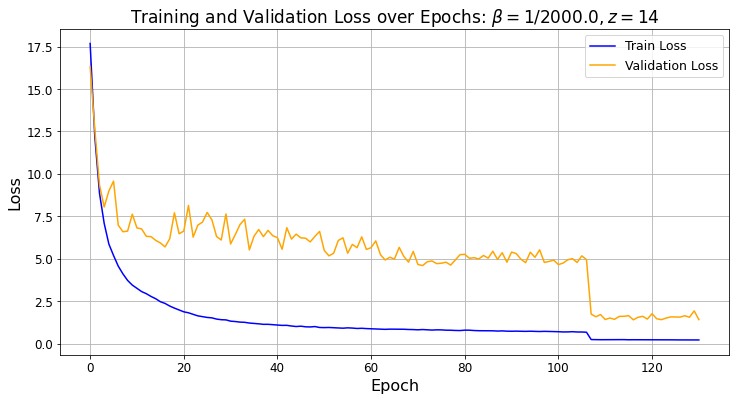

In [15]:
# plot training and validation losses over epochs
z = best_params['latent_dim']
#best_model.load_state_dict(torch.load("lcpb_files/best_model_overall.pt"))

train_loss_curve = np.array(best_trial.user_attrs["mean_train_loss_curve"])
val_loss_curve = np.array(best_trial.user_attrs["mean_val_loss_curve"])
val_vae_loss_curve = np.array(best_trial.user_attrs["mean_val_vae_loss_curve"])
val_regr_loss_curve = np.array(best_trial.user_attrs["mean_val_regr_loss_curve"])

# get only where the loss != 0 (early stopping eventuality)
epochs = np.arange(len(train_loss_curve[train_loss_curve!=0]))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve[train_loss_curve!=0], label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve[val_loss_curve!=0], label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(fr"Training and Validation Loss over Epochs: $\beta=1/{1./beeta},z={z}$")
plt.legend()
plt.grid(True)
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/3.2_train_val_loss.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

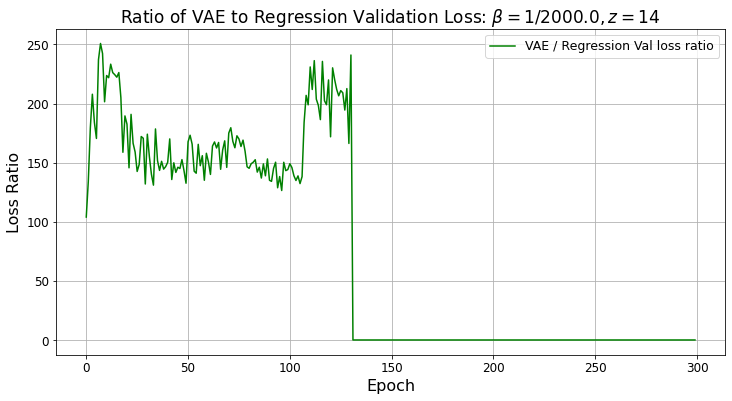

In [16]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero
epochs = np.arange(len(loss_ratio))

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio, label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(fr"Ratio of VAE to Regression Validation Loss: $\beta=1/{1./beeta},z={z}$")
plt.grid(True)
plt.legend()
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/3.2_val_loss_ratio.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

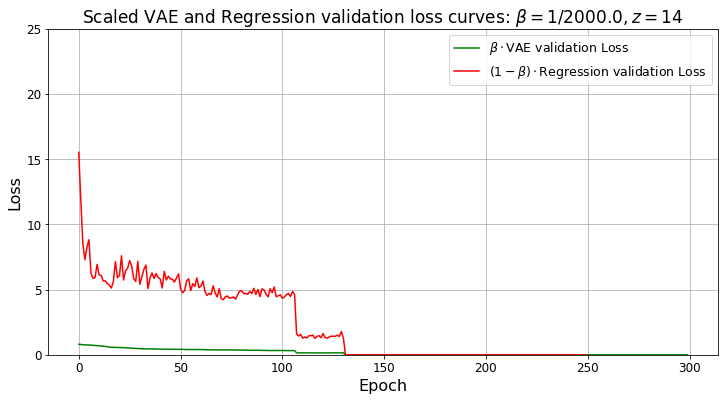

In [17]:
fig,ax= plt.subplots(figsize=(12,6))

ax.plot(epochs, beeta*val_vae_loss_curve, label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(fr"Scaled VAE and Regression validation loss curves: $\beta=1/{1./beeta},z={z}$")

ax.plot(epochs[:250], (1-beeta)*val_regr_loss_curve[:250], label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(0,25)
ax.grid(True)
ax.legend()
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/3.2_scaled_vae_regr_loss.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()


### 3.3: Model evaluation
The following cells perform a computation of the prediction of the label (this is still preliminary though) and plot the results

In [18]:
best_model.eval()

num_passes= 200

mean_preds = None

for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()
    recon_x = recon_x.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()


print(mean_test_predictions)

[[0.33985353]
 [0.7121097 ]
 [0.56159043]
 ...
 [0.78625643]
 [0.7024385 ]
 [0.6324203 ]]


In [19]:
print(np.shape(mean_test_predictions[:,0]))
print(np.shape(Y_test))

(1658,)
(1658,)


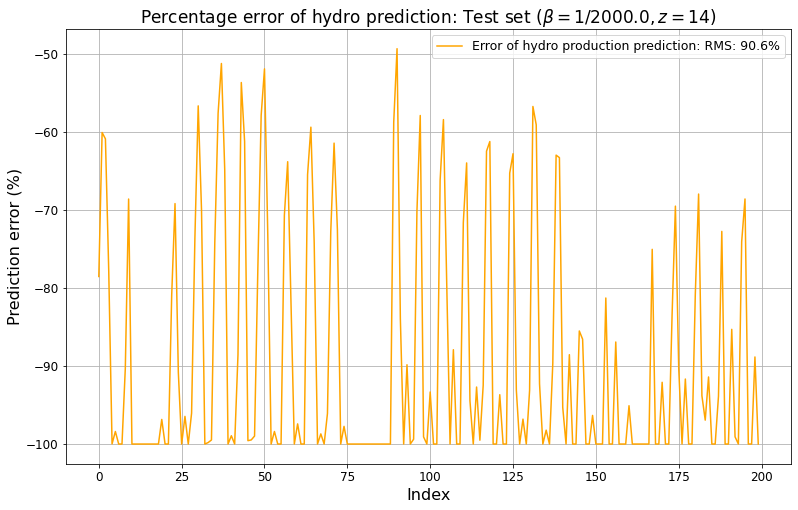

In [20]:
plt.figure(figsize=(13, 8))

# Mask zeros and very small values to avoid extreme divisions
epsilon = 1e-6
mask = np.where(np.abs(Y_test) > epsilon)[0]
masked_Y = Y_test[mask]
masked_pred = mean_test_predictions[mask,0]

# Limit points to plot
points_to_plot = min(200, len(masked_Y))

error_solar = (masked_pred[:points_to_plot] - masked_Y[:points_to_plot]) / masked_Y[:points_to_plot]
error_solar_percent = error_solar * 100

# Remove inf/nan values (just in case)
error_solar_percent = np.nan_to_num(error_solar_percent, nan=0.0, posinf=0.0, neginf=0.0)

plt.plot(np.arange(points_to_plot), error_solar_percent, color='orange',
         label=f'Error of {energies[target_index]} production prediction: RMS: {round(np.sqrt(np.mean(error_solar_percent**2)), 1)}%')

plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(fr"Percentage error of {energies[target_index]} prediction: Test set ($\beta=1/{1./beeta}, z={z}$)")
plt.grid(True)
plt.legend()

# Use lower dpi
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/3.3_label_prediction.png'
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()

## 4: Search for best $\beta$ parameter
The previous training was all about the structure. We did not run the search over $\beta$, which is the parameter that handles how losses interact, and so determines the effectiveness of our VAE in reducing the dimensionality aiming to a good regression performance. The following cells will try to handle it.

First of all, let's take the previous best parameters and save them. We are going to set these up for the training, this time looking for the best **$\beta$** parameter over a possible range

In [21]:
hd1 = best_params['hidden_dim1']
hd2 = best_params['hidden_dim2']
z = best_params['latent_dim']
hd3 = best_params['hidden_dim3']
n1 = best_params['N1']
n2 = best_params['N2']
ltk = best_params['lambda_tik']
learning_rate = best_params['lr']
act = best_params['activation']

# beta range and step
beta_min = 50
beta_max = 500
step = 50

### 4.1: Training definition
We train the same structure as before, this time fixing the geometry and tuning only $\beta$

In [22]:
# fix previous best hyper parameters and find best beta

def objective(trial):

    def get_activation(name):
        return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()}[name]

    beta = trial.suggest_float("beta",beta_min,beta_max, step = step) # choose a reasonable range according to previous results
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 250
    batch_size = 16
    num_folds = 2
    early_stop_patience = 35
    tscv = TimeSeriesSplit(n_splits= num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    best_val_loss = float('inf')
    best_model_state = None

    fold_val_regr_curves = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]
        
        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)
        
        lambda_tik = ltk
        
        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            hidden_dim1=hd1,
            hidden_dim2=hd2,
            latent_dim=z,
            hidden_dim3=hd3,
            vae_activation=get_activation('relu'),
            N1=n1,
            N2=n2,
            No=Y_train_fold.shape[1],
            activation=get_activation('relu'),
            lambda_tik=ltk
        ).to(device)

        lr =  learning_rate
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience= 20)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last = True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last = True)

        no_improve_counter = 0
        best_fold_loss = float('inf')
        fold_val_regr_curve = []

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1-1./beta) * regr_loss + 1./beta*vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - 1. / beta) * regr_loss + 1. / beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            epoch_train_losses[epoch] += (train_loss_epoch) / num_folds
            epoch_val_losses[epoch] += (val_loss_epoch) / num_folds
            epoch_val_vae_losses[epoch] += (val_vae_loss_epoch) / num_folds
            epoch_val_regr_losses[epoch] += (val_regr_loss_epoch) / num_folds

            fold_val_regr_curve.append(val_regr_loss_epoch)

            print(f"Epoch [{epoch + 1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_loss_epoch < best_fold_loss: # early stopping
                best_fold_loss = val_loss_epoch
                no_improve_counter = 0
            else:
                no_improve_counter += 1
                if no_improve_counter >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch + 1} in fold {fold + 1}")
                    break

            if val_loss_epoch < best_val_loss:
                best_val_loss = val_loss_epoch
                best_model_state = model.state_dict()

        fold_val_regr_curves.append(fold_val_regr_curve)

    fold_model_path = f"4_weights/{sel_zone}/{energies[target_index]}/beta_trial_{trial.number}_fold_{fold}.pt"
    torch.save(best_model_state, fold_model_path)
    trial.set_user_attr("model_path", fold_model_path)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    trial.set_user_attr("final_vae_loss", epoch_val_vae_losses[-1])
    trial.set_user_attr("final_regr_loss", epoch_val_regr_losses[-1])

    mean_last10_regr_losses = []
    for curve in fold_val_regr_curves:
        if len(curve) >= 10:
            mean_last10_regr_losses.append(np.mean(curve[-10:]))
        else:
            mean_last10_regr_losses.append(np.mean(curve))

    return float(np.mean(mean_last10_regr_losses))


The following cell runs the training (if it was not ran before). If there is already a study in memory, this cell can be skipped

In [23]:
from tqdm import tqdm
n_trials = 10

# get current day and month
day = date.today().day
month_name = date.today().strftime("%B")


max_jobs = min(n_trials, os.cpu_count() or 4)  # for SQLite, avoid too many writers

study_beta = optuna.create_study( study_name= f"{sel_zone}_{energies[target_index]}_study_beta", direction="minimize",
    storage=f"sqlite:///{sel_zone}_{energies[target_index]}_optuna.db",
    load_if_exists=True,pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=125))


study_beta.optimize(objective, n_trials=n_trials,n_jobs=1,catch=(Exception,))

[I 2025-07-05 11:00:03,903] A new study created in RDB with name: IT_NORD_hydro_study_beta


Epoch [1/250] - Total val loss: 10.1349, VAE: 810.9192, Regr: 8.3515
Epoch [2/250] - Total val loss: 8.8373, VAE: 798.9106, Regr: 7.0777
Epoch [3/250] - Total val loss: 7.4828, VAE: 761.9836, Regr: 5.8024
Epoch [4/250] - Total val loss: 6.7543, VAE: 737.1242, Regr: 5.1276
Epoch [5/250] - Total val loss: 6.3974, VAE: 730.8355, Regr: 4.7840
Epoch [6/250] - Total val loss: 6.0731, VAE: 757.9036, Regr: 4.3987
Epoch [7/250] - Total val loss: 6.7873, VAE: 736.7479, Regr: 5.1615
Epoch [8/250] - Total val loss: 6.2517, VAE: 668.3544, Regr: 4.7771
Epoch [9/250] - Total val loss: 5.8906, VAE: 607.1639, Regr: 4.5515
Epoch [10/250] - Total val loss: 5.8809, VAE: 582.1745, Regr: 4.5974
Epoch [11/250] - Total val loss: 6.0950, VAE: 550.9877, Regr: 4.8814
Epoch [12/250] - Total val loss: 5.9898, VAE: 545.3317, Regr: 4.7886
Epoch [13/250] - Total val loss: 6.3853, VAE: 530.7014, Regr: 5.2175
Epoch [14/250] - Total val loss: 6.0924, VAE: 502.4240, Regr: 4.9870
Epoch [15/250] - Total val loss: 7.0859, V

[I 2025-07-05 11:05:22,841] Trial 0 finished with value: 5.570875826612978 and parameters: {'beta': 450.0}. Best is trial 0 with value: 5.570875826612978.


Epoch [107/250] - Total val loss: 9.1896, VAE: 542.5795, Regr: 8.0017
Early stopping at epoch 107 in fold 2
Epoch [1/250] - Total val loss: 12.6338, VAE: 807.4710, Regr: 8.6396
Epoch [2/250] - Total val loss: 10.2618, VAE: 774.0235, Regr: 6.4238
Epoch [3/250] - Total val loss: 8.9889, VAE: 748.3373, Regr: 5.2736
Epoch [4/250] - Total val loss: 8.2399, VAE: 732.6012, Regr: 4.5999
Epoch [5/250] - Total val loss: 8.0171, VAE: 721.0176, Regr: 4.4341
Epoch [6/250] - Total val loss: 8.1979, VAE: 694.4708, Regr: 4.7492
Epoch [7/250] - Total val loss: 7.3702, VAE: 634.5547, Regr: 4.2185
Epoch [8/250] - Total val loss: 7.1913, VAE: 568.9631, Regr: 4.3683
Epoch [9/250] - Total val loss: 7.0821, VAE: 551.2282, Regr: 4.3477
Epoch [10/250] - Total val loss: 6.8922, VAE: 476.0404, Regr: 4.5347
Epoch [11/250] - Total val loss: 6.8751, VAE: 434.4569, Regr: 4.7264
Epoch [12/250] - Total val loss: 7.3836, VAE: 387.1020, Regr: 5.4755
Epoch [13/250] - Total val loss: 5.8915, VAE: 359.3456, Regr: 4.1153
Ep

[I 2025-07-05 11:08:46,953] Trial 1 finished with value: 6.7788383343189516 and parameters: {'beta': 200.0}. Best is trial 0 with value: 5.570875826612978.


...

Epoch [161/250] - Total val loss: 13.8393, VAE: 527.9312, Regr: 3.3476
Early stopping at epoch 161 in fold 2
Epoch [1/250] - Total val loss: 11.3975, VAE: 831.7757, Regr: 8.6537
Epoch [2/250] - Total val loss: 8.4837, VAE: 785.7854, Regr: 5.8840
Epoch [3/250] - Total val loss: 7.4832, VAE: 737.2549, Regr: 5.0425
Epoch [4/250] - Total val loss: 6.9637, VAE: 717.1335, Regr: 4.5886
Epoch [5/250] - Total val loss: 7.1944, VAE: 705.8146, Regr: 4.8579
Epoch [6/250] - Total val loss: 6.5022, VAE: 697.6566, Regr: 4.1907
Epoch [7/250] - Total val loss: 6.4450, VAE: 664.4009, Regr: 4.2445
Epoch [8/250] - Total val loss: 7.1264, VAE: 633.0774, Regr: 5.0329
Epoch [9/250] - Total val loss: 7.3359, VAE: 582.0110, Regr: 5.4139
Epoch [10/250] - Total val loss: 7.5802, VAE: 537.8242, Regr: 5.8068
Epoch [11/250] - Total val loss: 7.1864, VAE: 510.3466, Regr: 5.5036
Epoch [12/250] - Total val loss: 6.3935, VAE: 481.0599, Regr: 4.8060
Epoch [13/250] - Total val loss: 6.1216, VAE: 455.9933, Regr: 4.6170
Ep

[I 2025-07-05 11:35:24,325] Trial 8 finished with value: 5.249414042145878 and parameters: {'beta': 300.0}. Best is trial 7 with value: 3.490187712602209.


Epoch [123/250] - Total val loss: 6.9943, VAE: 524.0248, Regr: 5.2651
Early stopping at epoch 123 in fold 2
Epoch [1/250] - Total val loss: 10.2351, VAE: 809.5888, Regr: 8.4548
Epoch [2/250] - Total val loss: 7.9513, VAE: 795.9930, Regr: 6.1962
Epoch [3/250] - Total val loss: 6.6566, VAE: 775.9031, Regr: 4.9433
Epoch [4/250] - Total val loss: 5.7836, VAE: 770.5696, Regr: 4.0803
Epoch [5/250] - Total val loss: 5.4287, VAE: 729.2062, Regr: 3.8167
Epoch [6/250] - Total val loss: 4.9079, VAE: 723.1790, Regr: 3.3081
Epoch [7/250] - Total val loss: 4.6114, VAE: 705.2819, Regr: 3.0509
Epoch [8/250] - Total val loss: 4.6771, VAE: 693.0472, Regr: 3.1440
Epoch [9/250] - Total val loss: 4.5297, VAE: 676.9123, Regr: 3.0322
Epoch [10/250] - Total val loss: 5.0387, VAE: 639.7476, Regr: 3.6251
Epoch [11/250] - Total val loss: 5.2554, VAE: 623.5889, Regr: 3.8783
Epoch [12/250] - Total val loss: 5.2187, VAE: 583.2251, Regr: 3.9314
Epoch [13/250] - Total val loss: 5.8598, VAE: 532.8915, Regr: 4.6860
Epo

[I 2025-07-05 11:37:53,029] Trial 9 finished with value: 6.626350539658165 and parameters: {'beta': 450.0}. Best is trial 7 with value: 3.490187712602209.


Epoch [81/250] - Total val loss: 2.5050, VAE: 259.0467, Regr: 1.9337
Early stopping at epoch 81 in fold 2


### 4.2: Retrieving the best model and final results (Retraining on best params)

In [24]:
day = date.today().day
month_name = date.today().strftime("%B")

study_beta = optuna.load_study(
    study_name= f"{sel_zone}_{energies[target_index]}_study_beta",
    storage=f"sqlite:///{sel_zone}_{energies[target_index]}_optuna.db"
)

best_trial = study_beta.best_trial
best_params = best_trial.params
best_params

{'beta': 50.0}

In [25]:
# final training for the best hyper-parameters found

import os
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


best_trial= study_beta.best_trial
best_params= best_trial.params
beta = 1./best_params['beta']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lambda_tik= ltk
best_model = VAE_Regression(
     input_dim=X_train_tensor.shape[1],
     hidden_dim1=hd1,
     hidden_dim2=hd2,
     latent_dim=z,
     hidden_dim3=hd3,
     vae_activation=get_activation('relu'),
     N1=n1,
     N2=n2,
     No=Y_train_tensor.shape[1],
     activation=get_activation('relu'),
     lambda_tik=lambda_tik).to(device)

# REMOVE NAN
# Get mask for rows that are valid (no NaNs in any Y_test_tensor column)
valid_mask = ~torch.isnan(Y_test_tensor).any(dim=1)

# Apply mask to both X and Y tensors
X_test_tensor = X_test_tensor[valid_mask]
Y_test_tensor = Y_test_tensor[valid_mask]


train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=16, shuffle=True, drop_last = True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  Y_test_tensor),  batch_size=16, shuffle=False, drop_last = False)

num_epochs = 250
#beta       = 1/550.0 # best previously found
patience   = 35

train_curve     = []
test_curve      = []
test_vae_curve  = []
test_regr_curve = []

optimizer = torch.optim.Adam(best_model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=20)

best_test = float("inf")
no_imp    = 0
best_state= None

for ep in range(num_epochs):
    best_model.train()
    train_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, recon, mu, logvar, _ = best_model(xb)
        vl = best_model.VAE_loss(recon, xb, mu, logvar)[0]
        rl = best_model.regression_loss(yb, pred, lambda_tik)
        loss = (1-beta)*rl + beta*vl
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        optimizer.step()
        train_sum += loss.item()
    train_curve.append(train_sum/len(train_loader))

    best_model.eval()
    t_sum = v_sum = r_sum = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred, recon, mu, logvar, _ = best_model(xb)
            vl = best_model.VAE_loss(recon, xb, mu, logvar)[0].item()
            rl = best_model.regression_loss(yb, pred,lambda_tik).item()
            t_sum += (1-beta)*rl + beta*vl
            v_sum += vl
            r_sum += rl
    te = t_sum/len(test_loader)
    tv = v_sum/len(test_loader)
    tr = r_sum/len(test_loader)
    test_curve.append(te)
    test_vae_curve.append(tv)
    test_regr_curve.append(tr)

    print(f"Epoch {ep+1}/{num_epochs} - Val Total: {te:.4f}, VAE: {tv:.4f}, Regr: {tr:.4f}")

    
    if tr < best_test:
        best_test = tr
        best_state= best_model.state_dict()
        no_imp    = 0
    else:
        no_imp += 1
        if no_imp >= patience:
            break

best_model.load_state_dict(best_state)
os.makedirs(f"best_Regr_models/Single_{energies[target_index]}", exist_ok=True)
torch.save(best_state, f"best_Regr_models/Single_{energies[target_index]}/best_model_{energies[target_index]}_{day}{month_name}_{sel_zone}_FINAL.pt")

train_loss_curve    = np.array(train_curve)
val_loss_curve      = np.array(test_curve)
val_vae_loss_curve  = np.array(test_vae_curve)
val_regr_loss_curve = np.array(test_regr_curve)


Epoch 1/250 - Val Total: 42.2676, VAE: 1545.5188, Regr: 11.5890
Epoch 2/250 - Val Total: 28.7924, VAE: 1067.8792, Regr: 7.5866
Epoch 3/250 - Val Total: 18.3144, VAE: 635.9445, Regr: 5.7097
Epoch 4/250 - Val Total: 16.0199, VAE: 537.2212, Regr: 5.3831
Epoch 5/250 - Val Total: 15.6934, VAE: 516.0436, Regr: 5.4822
Epoch 6/250 - Val Total: 15.4974, VAE: 492.5368, Regr: 5.7619
Epoch 7/250 - Val Total: 13.3072, VAE: 473.0449, Regr: 3.9248
Epoch 8/250 - Val Total: 12.5275, VAE: 452.6635, Regr: 3.5452
Epoch 9/250 - Val Total: 12.3905, VAE: 445.7275, Regr: 3.5469
Epoch 10/250 - Val Total: 11.6435, VAE: 441.9391, Regr: 2.8620
Epoch 11/250 - Val Total: 11.5161, VAE: 440.2268, Regr: 2.7669
Epoch 12/250 - Val Total: 11.5398, VAE: 431.1426, Regr: 2.9765
Epoch 13/250 - Val Total: 10.9554, VAE: 426.4242, Regr: 2.4764
Epoch 14/250 - Val Total: 10.7471, VAE: 417.5478, Regr: 2.4450
Epoch 15/250 - Val Total: 10.8900, VAE: 417.2550, Regr: 2.5969
Epoch 16/250 - Val Total: 10.1490, VAE: 408.3777, Regr: 2.021

# 5: Visualization of reconstructed features and final results
### 5.1: final results and losses
This final section plots all important information about our final model. What we get is an efficient machine that can perform a regression on a specific energy type given the selected zone's data. The RMS (error) varies based on the zone and on the type, since different energy types behave differently: some are more correlated to forecast and geographical location, some are less. 

In [27]:
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_pred_vs_test_final.png'

best_model.eval()
num_passes = 100

mean_preds = None
for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()

mean_test_predictions

array([[1.5642759],
       [1.7072679],
       [1.3492295],
       ...,
       [1.1246116],
       [1.0212885],
       [1.0282823]], dtype=float32)

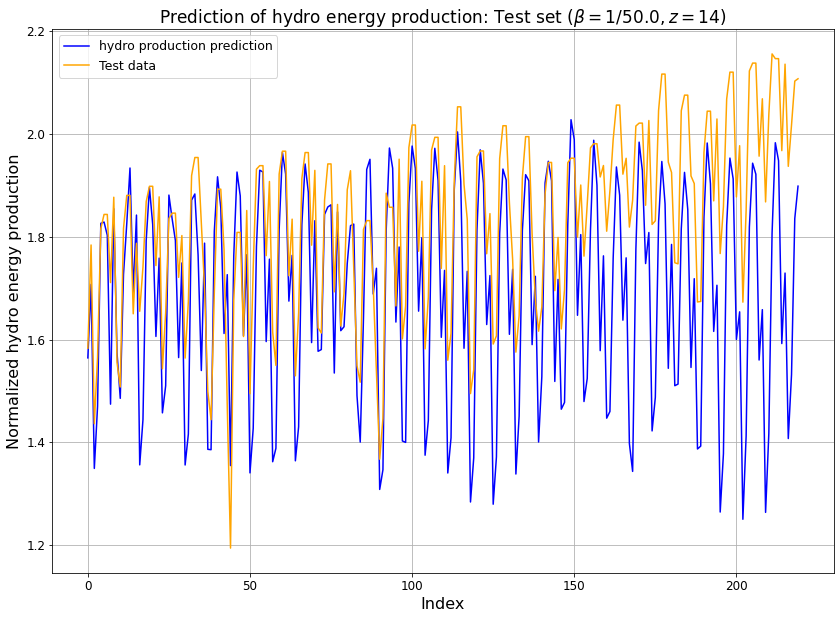

In [28]:
plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
    })

points_to_plot = 220
energy_colors = ['red','green','blue']

plt.figure(figsize = (14,10))
plt.plot(np.arange(points_to_plot),mean_test_predictions[:points_to_plot], color = energy_colors[target_index], label = f'{energies[target_index]} production prediction')
plt.plot(np.arange(points_to_plot),Y_test[:points_to_plot],color ='orange', label = 'Test data')
plt.xlabel("Index")
plt.ylabel(f"Normalized {energies[target_index]} energy production")
plt.title(fr"Prediction of {energies[target_index]} energy production: Test set ($\beta=1/{best_params['beta']}, z={z}$)")
plt.grid(True)
plt.legend()
#plt.ylim(1,max(Y_test[:points_to_plot])+0.2)
plt.savefig(filepath, dpi = 300, bbox_inches = 'tight')
plt.show()

The following plot gives a graphical idea of our results: if the point distribution is close to the line, the regression is performing well. 

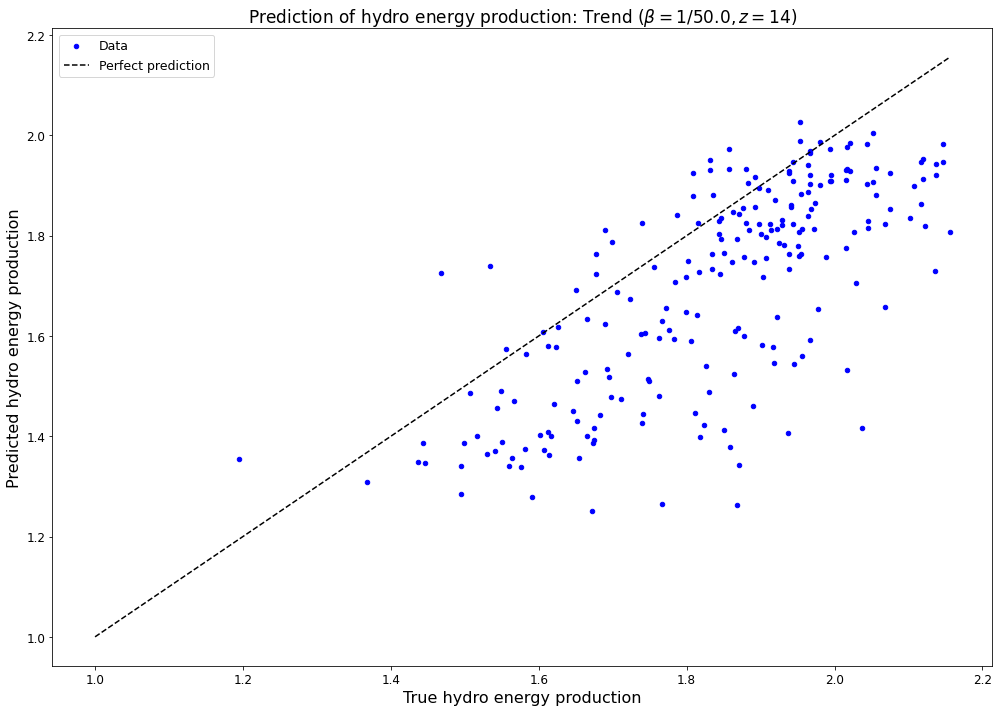

In [30]:
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_pred_vs_test_baiesi_style.png'

plt.figure(figsize = (14,10))
plt.scatter(Y_test[:points_to_plot],mean_test_predictions[:points_to_plot], color = energy_colors[target_index], label = f'Data',
            s = 20)
plt.plot(np.linspace(1,max(Y_test[:points_to_plot]),points_to_plot),np.linspace(1,max(Y_test[:points_to_plot]),points_to_plot), linestyle = '--', color = 'black', label = 'Perfect prediction')
plt.xlabel(f"True {energies[target_index]} energy production")
plt.ylabel(f"Predicted {energies[target_index]} energy production")
plt.title(fr"Prediction of {energies[target_index]} energy production: Trend ($\beta=1/{best_params['beta']}, z={z}$)")
plt.legend()
plt.tight_layout()
plt.savefig(filepath, dpi = 300, bbox_inches = 'tight')
plt.show()


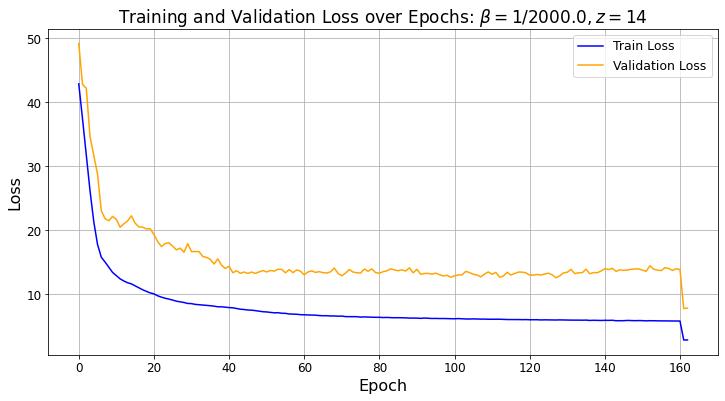

In [31]:
# plot training and validation losses over epochs
#best_model.load_state_dict(torch.load("lcpb_files/best_model_overall.pt"))

train_loss_curve = np.array(best_trial.user_attrs["mean_train_loss_curve"])
val_loss_curve = np.array(best_trial.user_attrs["mean_val_loss_curve"])
val_vae_loss_curve = np.array(best_trial.user_attrs["mean_val_vae_loss_curve"])
val_regr_loss_curve = np.array(best_trial.user_attrs["mean_val_regr_loss_curve"])

# get only where the loss != 0 (early stopping eventuality)
epochs = np.arange(len(train_loss_curve[train_loss_curve!=0]))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve[train_loss_curve!=0], label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve[val_loss_curve!=0], label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(fr"Training and Validation Loss over Epochs: $\beta=1/{1./beeta},z={z}$")
plt.legend()
plt.grid(True)
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_train_val_loss.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

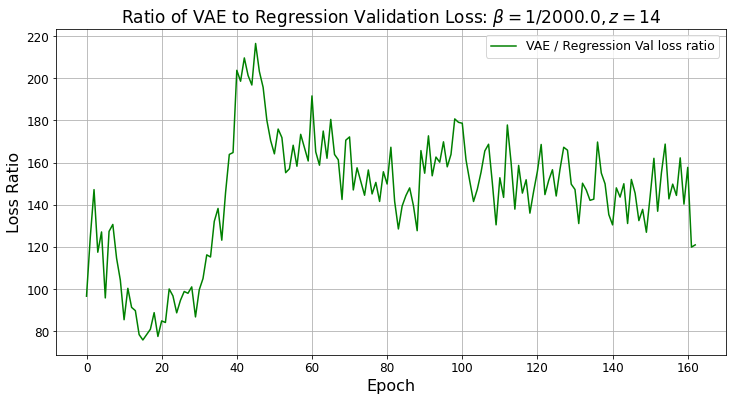

In [32]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero
loss_ratio = loss_ratio[loss_ratio > 0]
epochs = np.arange(len(loss_ratio))

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio, label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(fr"Ratio of VAE to Regression Validation Loss: $\beta=1/{1./beeta},z={z}$")
plt.grid(True)
plt.legend()
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_val_loss_ratio.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

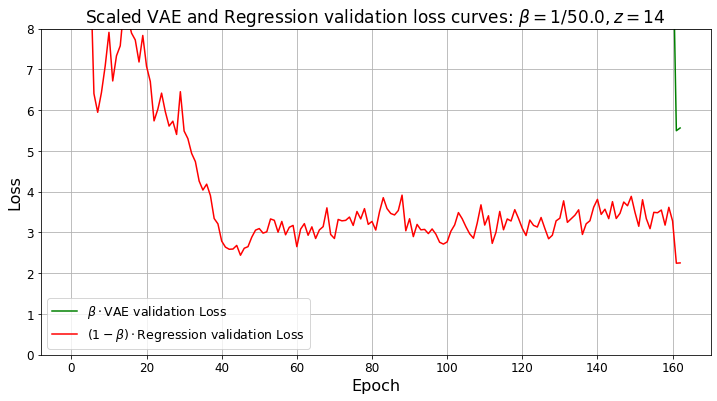

In [34]:
mask = np.where(val_vae_loss_curve != 0)[0]

fig,ax= plt.subplots(figsize=(12,6))
epochs = np.arange(250)
ax.plot(epochs[mask], beta*val_vae_loss_curve[mask], label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(fr"Scaled VAE and Regression validation loss curves: $\beta=1/{1./beta},z={z}$")

ax.plot(epochs[mask], (1-beta)*val_regr_loss_curve[mask], label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(0,8)
ax.grid(True)
ax.legend()
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_scaled_vae_regr_loss.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()


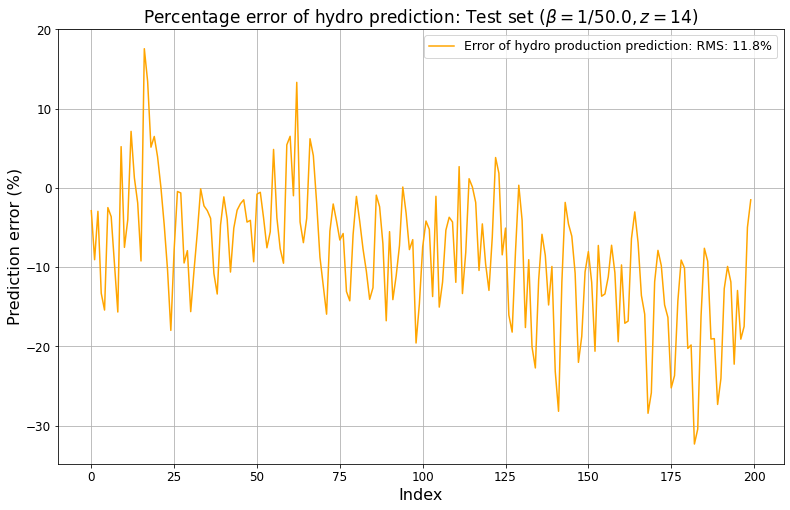

In [35]:
plt.figure(figsize=(13, 8))

bias = 27

# Mask zeros and very small values to avoid extreme divisions
epsilon = 0.01
mask = np.where(np.abs(Y_test) > epsilon)[0]
masked_Y = Y_test[mask]
masked_pred = mean_test_predictions[mask,0]


# masking also errors in predictions
mask2 = np.where(masked_pred > epsilon)[0]
masked_Y = masked_Y[mask2]
masked_pred = masked_pred[mask2]

# Limit points to plot
points_to_plot = min(200, len(masked_Y))

error_solar = (masked_pred[bias:(bias+points_to_plot)] - masked_Y[bias:(bias+points_to_plot)]) / masked_Y[bias:(bias+points_to_plot)]
error_solar_percent = error_solar * 100

# Remove inf/nan values (just in case)
error_solar_percent = np.nan_to_num(error_solar_percent, nan=0.0, posinf=0.0, neginf=0.0)

plt.plot(np.arange(points_to_plot), error_solar_percent, color='orange',
         label=f'Error of {energies[target_index]} production prediction: RMS: {round(np.sqrt(np.mean(error_solar_percent**2)), 1)}%')

plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(fr"Percentage error of {energies[target_index]} prediction: Test set ($\beta=1/{1./beta}, z={z}$)")
plt.grid(True)
plt.legend()

# Use lower dpi
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/5.1_error_prediction.png'
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()

### 5.2: reconstructing features
We also want the VAE to be able to reconstruct features. Its main goal is to reduce the dimensionality of the problem, while still making sure to retrieve all data's relevant information in the latent space. If the VAE is able to reconstruct the original features from the latent space's representation, this is a good sign that it's doing its job well.

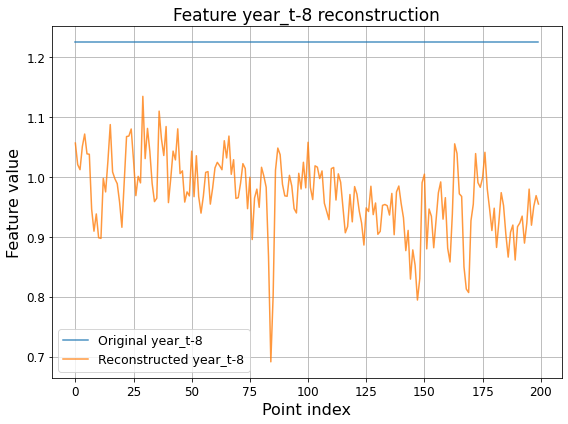

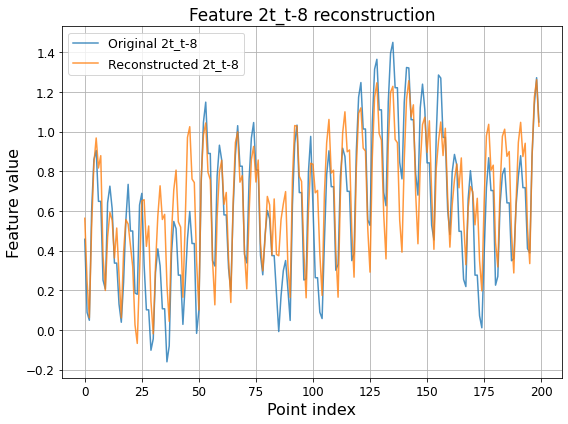

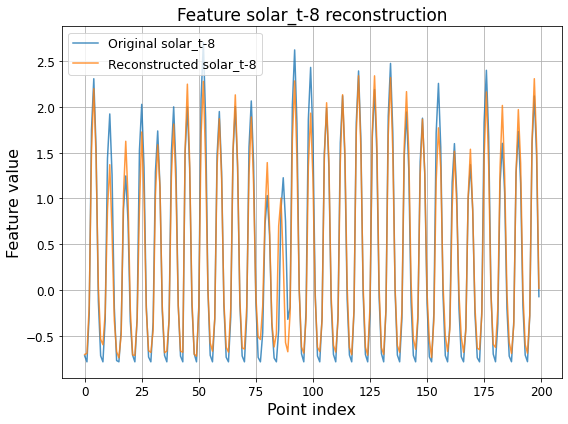

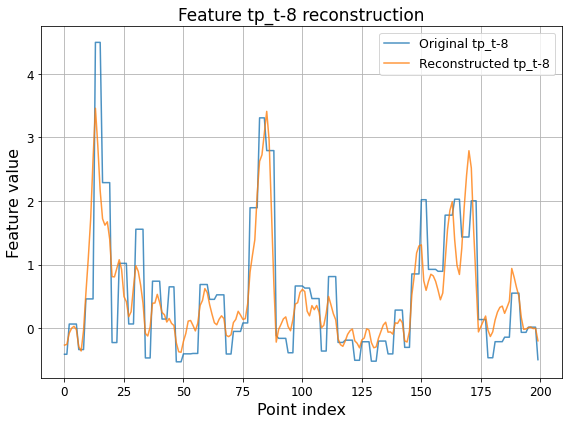

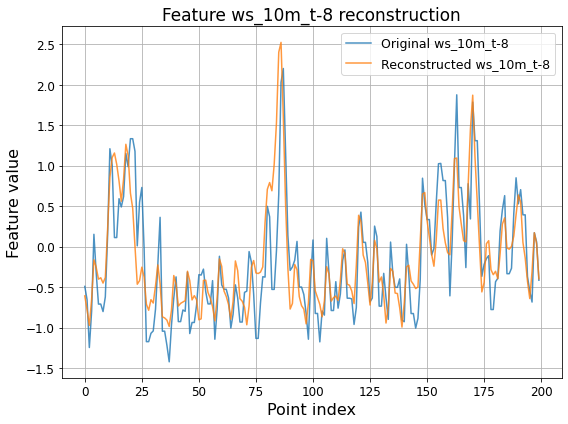

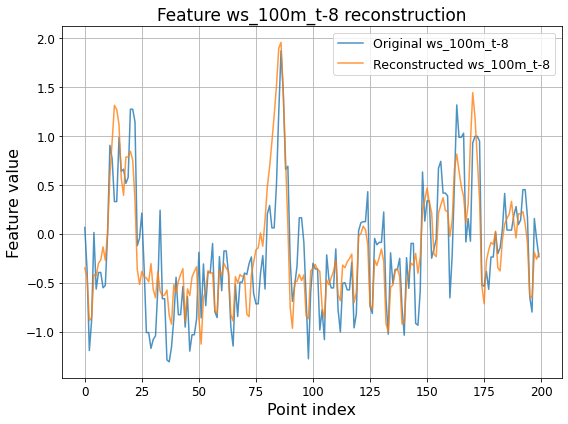

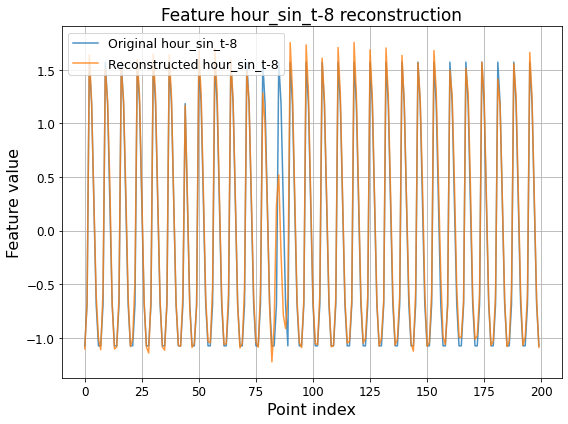

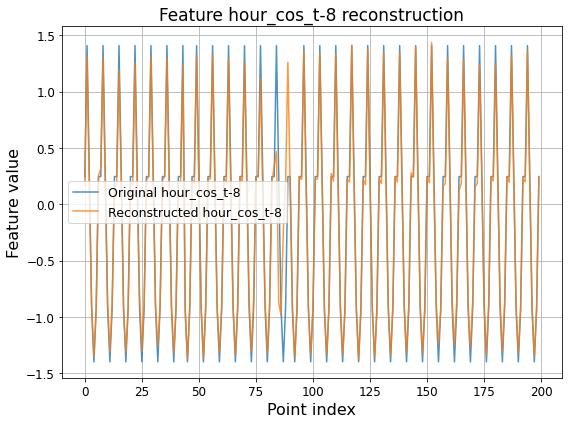

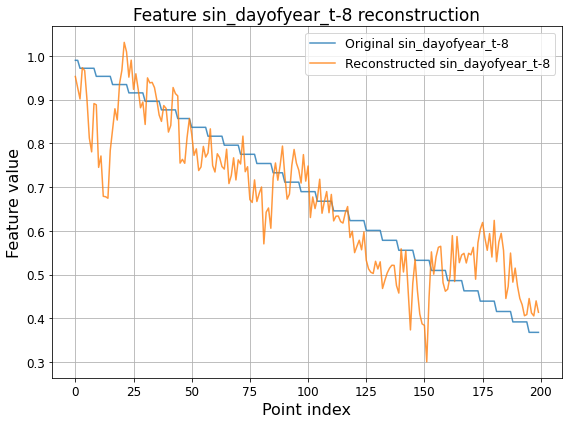

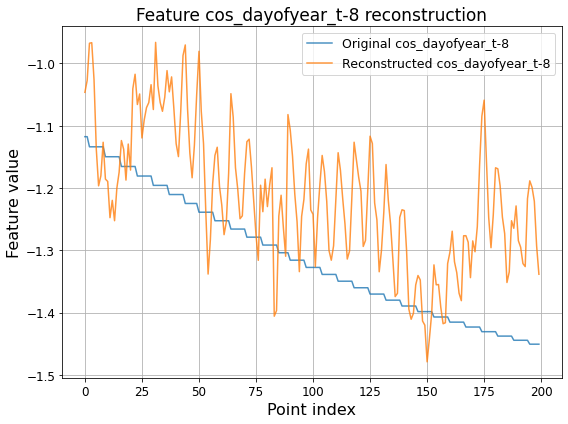

In [36]:
original_all = X_test
reconstructed_all = mean_recon_x_test

feature_names = df_features.drop(columns = ['timestamp']).columns.tolist()
features_to_plot = np.arange(0,10,1)

points_to_plot = 200
dummy_x = np.arange(points_to_plot)

for feature_idx in features_to_plot:
    plt.figure(figsize = (8,6))
    plt.plot(dummy_x,
            original_all[:points_to_plot,feature_idx],
            alpha = 0.8,
            label = f'Original {feature_names[feature_idx]}')
    plt.plot(dummy_x,
            reconstructed_all[:points_to_plot,feature_idx],
            alpha = 0.8,
            label = f'Reconstructed {feature_names[feature_idx]}')
    plt.xlabel('Point index')
    plt.ylabel('Feature value')
    plt.title(f'Feature {feature_names[feature_idx]} reconstruction')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename = f'4_plots/{sel_zone}/{energies[target_index]}/5.2_VAE_reconstruction_feature_{feature_idx}.png'
    plt.savefig(filename, dpi = 300, bbox_inches = 'tight')
    plt.show()

# 6: Solo NN regression comparsion
In this section we train just a NN (we remove the VAE from the architecture) to compare the results and see which model performs best

### 6.1: Model and Training

In [37]:
class SimpleRegressor(nn.Module):
  def __init__(self, input_dim, hidden_dims, output_dim, activation_fn, dropout_prob = 0.1):
    super(SimpleRegressor, self).__init__()

    #first hidden layer
    self.fc1 = nn.Linear(input_dim, hidden_dims[0])
    self.batch1 = nn.BatchNorm1d(hidden_dims[0])
    self.drop1 = nn.Dropout(p = dropout_prob)

    #second hidden layer
    self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
    self.batch2 = nn.BatchNorm1d(hidden_dims[1])
    self.drop2 = nn.Dropout(p = dropout_prob)

    #output layer
    self.out = nn.Linear(hidden_dims[1], output_dim)
    self.activation = activation_fn

  def forward(self, x):
    x_lin = self.fc1(x)
    x_bat = self.batch1(x_lin)
    x_act = self.activation(x_bat)
    h1 = self.drop1(x_act)

    x_lin = self.fc2(h1)
    x_bat = self.batch2(x_lin)
    x_act = self.activation(x_bat)
    h2 = self.drop2(x_act)

    out = self.out(h2)
    return out

  def regr_loss(self, y, output, lambda_tik):
    mse = F.mse_loss(output, y, reduction='mean')

    w_norm = 0.0
    for param in self.parameters():
        w_norm += torch.sum((param)**2)

    return mse + lambda_tik * w_norm

In [38]:
def training(model, train_loader, val_loader, optimizer, device, num_epochs, lambda_tik, trial=None):
  history = {
      'train_loss': [],
      'val_loss': [],
      'actual_epochs': 0
  }

  # early stopping
  patience = 10
  best_val_loss = float('inf')
  epochs_no_improve = 0
  best_model_state = None

  for epoch in range(num_epochs):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    model.train()
    running_train_loss = 0.0

    for x, y in loop:
      x, y = x.to(device), y.to(device)
      y = y.view(-1, 1)

      optimizer.zero_grad()
      preds = model(x)
      loss = model.regr_loss(y, preds, lambda_tik)
      loss.backward()
      optimizer.step()
      running_train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
      for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        y = y.view(-1, 1)

        preds = model(x)
        loss = model.regr_loss(y, preds, lambda_tik)
        val_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"[Epoch {epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    # for Optuna prune
    if trial is not None:
      trial.report(avg_val_loss, step=epoch)

      if trial.should_prune():
        print(f"Pruned at epoch {epoch+1}")
        raise optuna.exceptions.TrialPruned()

    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      epochs_no_improve = 0
      best_model_state = copy.deepcopy(model.state_dict())
    else:
      epochs_no_improve += 1
      if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

  if best_model_state is not None:
    model.load_state_dict(best_model_state)

  history['actual_epochs'] = epoch + 1

  return history

### 6.2: Optuna trial and training

In [45]:
def objective(trial):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Sample hyperparams
  hidden_dims = trial.suggest_categorical("hidden_dims", [(32, 16), (16, 8), (8, 4)])
  dropout = trial.suggest_float("dropout", 0.3, 0.8, step=0.1)
  lambda_tik = trial.suggest_float("lambda_tik", 1e-4, 1e2, log=True)
  lr = trial.suggest_categorical("lr", [1e-5, 1e-4, 1e-3])
  batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
  #weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
  val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

  # Model
  model = SimpleRegressor(
      input_dim=X_array.shape[1],
      hidden_dims=hidden_dims,
      output_dim=1,
      activation_fn=nn.ReLU(),
      dropout_prob=dropout
  ).to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)

  # Train with early stopping
  history = training(model, train_loader, val_loader, optimizer, device, num_epochs=50, lambda_tik=lambda_tik, trial=trial)

  return min(history['val_loss'])

In [48]:
studyNN = optuna.create_study(study_name= f"{sel_zone}_soloNN_{energies[target_index]}",
                            direction="minimize", 
                            storage=f"sqlite:///{sel_zone}_soloNN_{energies[target_index]}_optuna.db",
                            load_if_exists=True,
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=125))
studyNN.optimize(objective, n_trials=50)


[I 2025-07-05 12:15:10,661] Using an existing study with name 'IT_NORD_soloNN_hydro' instead of creating a new one.
Epoch 1/50: 100%|████████████████████████████| 828/828 [00:01<00:00, 585.64it/s]


[Epoch 1/50] Train Loss: 0.5091, Val Loss: 0.4757


Epoch 2/50: 100%|████████████████████████████| 828/828 [00:01<00:00, 585.96it/s]


[Epoch 2/50] Train Loss: 0.2137, Val Loss: 0.3051


Epoch 3/50: 100%|████████████████████████████| 828/828 [00:01<00:00, 582.03it/s]


...

[Epoch 18/50] Train Loss: 0.1149, Val Loss: 0.1803


Epoch 19/50: 100%|███████████████████████████| 828/828 [00:01<00:00, 598.30it/s]


[Epoch 19/50] Train Loss: 0.1165, Val Loss: 0.1591


Epoch 20/50: 100%|███████████████████████████| 828/828 [00:01<00:00, 602.36it/s]
[I 2025-07-05 12:39:59,066] Trial 53 finished with value: 0.14569423490096456 and parameters: {'hidden_dims': [8, 4], 'dropout': 0.3, 'lambda_tik': 0.0004007574969114684, 'lr': 0.0001, 'batch_size': 8}. Best is trial 48 with value: 0.1141804553156432.


[Epoch 20/50] Train Loss: 0.1125, Val Loss: 0.1492
Early stopping at epoch 20


### 6.3: Best results retrieval and plot of results

In [49]:
studyNN = optuna.load_study(
    study_name= f"{sel_zone}_soloNN_{energies[target_index]}",
    storage=f"sqlite:///{sel_zone}_soloNN_{energies[target_index]}_optuna.db"
)

best_trial = studyNN.best_trial
best_params = best_trial.params

print("Best hyperparameters found:")
for k, v in best_params.items():
  print(f"  {k}: {v}")

Best hyperparameters found:
  hidden_dims: [16, 8]
  dropout: 0.3
  lambda_tik: 0.0014138781179578958
  lr: 0.001
  batch_size: 8


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_epochs = 250
hidden_dims = best_params['hidden_dims']
lr = best_params['lr']
batch_size = best_params['batch_size']
#weight_decay = best_params['weight_decay']
dropout_prob = best_params['dropout']
lambda_tik = best_params['lambda_tik']

final_model = SimpleRegressor(
    input_dim = X_array.shape[1],
    hidden_dims = hidden_dims,
    output_dim = 1,
    activation_fn = nn.ReLU(),
    dropout_prob = dropout_prob
).to(device)

optimizer = optim.Adam(final_model.parameters(), lr=lr, weight_decay=0)

train_final_dataset = train_dataset
final_train_loader = DataLoader(train_final_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Train with early stopping
final_history = training(final_model, final_train_loader, test_loader, optimizer, device, num_epochs=num_epochs, lambda_tik=lambda_tik, trial=None)

Epoch 1/250: 100%|███████████████████████████| 828/828 [00:01<00:00, 590.05it/s]


[Epoch 1/250] Train Loss: 0.4626, Val Loss: 0.2752


Epoch 2/250: 100%|███████████████████████████| 828/828 [00:01<00:00, 589.42it/s]


[Epoch 2/250] Train Loss: 0.1866, Val Loss: 0.2395


Epoch 3/250: 100%|███████████████████████████| 828/828 [00:01<00:00, 588.97it/s]


...

[Epoch 16/250] Train Loss: 0.0931, Val Loss: 0.1316


Epoch 17/250: 100%|██████████████████████████| 828/828 [00:01<00:00, 582.65it/s]


[Epoch 17/250] Train Loss: 0.0941, Val Loss: 0.1350


Epoch 18/250: 100%|██████████████████████████| 828/828 [00:01<00:00, 580.32it/s]


[Epoch 18/250] Train Loss: 0.0937, Val Loss: 0.1259
Early stopping at epoch 18


In [53]:
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/6.3_soloNN_pred_vs_test_final.png'

final_model.eval()
num_passes = 100

mean_preds = None
for i in range(num_passes):
    #regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    #regr_output = regr_output.cpu()
    preds = final_model(X_test_tensor.to(device)).cpu()

    if mean_preds is None:
        mean_preds = preds.clone()
    else:
        delta = preds - mean_preds
        mean_preds += delta / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
#mean_recon_x_test = mean_recons.detach().numpy()

mean_test_predictions

array([[1.3795011 ],
       [1.5107448 ],
       [1.2911146 ],
       ...,
       [1.0193553 ],
       [0.9904121 ],
       [0.91354793]], dtype=float32)

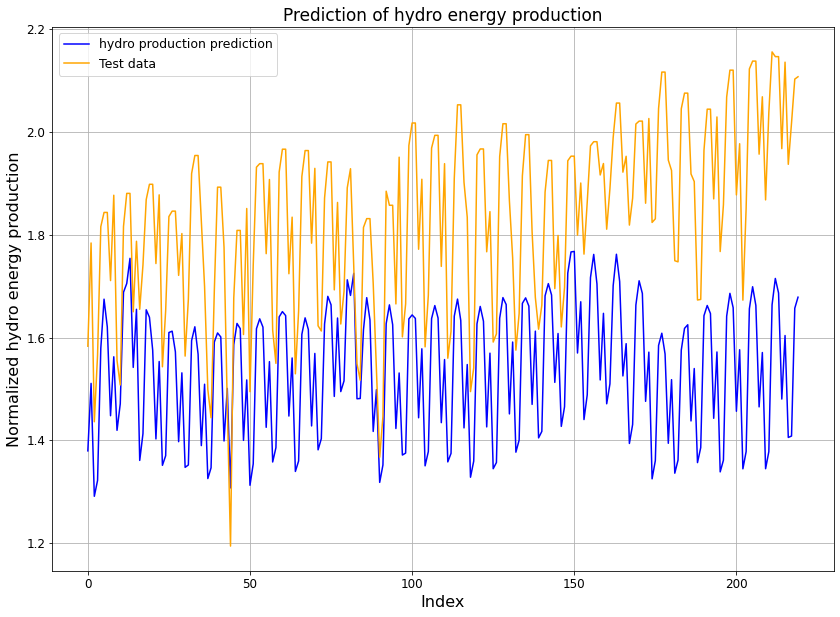

In [54]:
plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
    })

points_to_plot = 220
energy_colors = ['red','green','blue']

plt.figure(figsize = (14,10))
plt.plot(np.arange(points_to_plot),mean_test_predictions[:points_to_plot], color = energy_colors[target_index], label = f'{energies[target_index]} production prediction')
plt.plot(np.arange(points_to_plot),Y_test[:points_to_plot],color ='orange', label = 'Test data')
plt.xlabel("Index")
plt.ylabel(f"Normalized {energies[target_index]} energy production")
plt.title(fr"Prediction of {energies[target_index]} energy production")#: Test set ($\beta=1/{best_params['beta']}, z={z}$)")
plt.grid(True)
plt.legend()
#plt.ylim(1,max(Y_test[:points_to_plot])+0.2)
plt.savefig(filepath, dpi = 300, bbox_inches = 'tight')
plt.show()

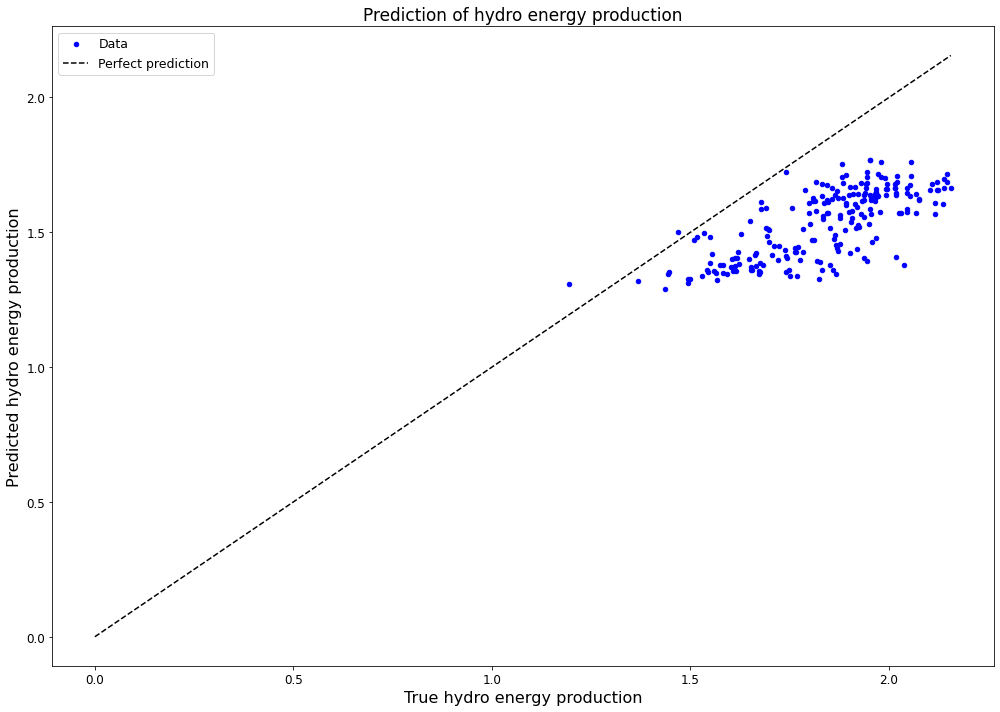

In [55]:
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/6.3_soloNN_pred_vs_test_baiesi_style.png'

plt.figure(figsize = (14,10))
plt.scatter(Y_test[:points_to_plot],mean_test_predictions[:points_to_plot], color = energy_colors[target_index], label = f'Data',
            s = 20)
plt.plot(np.linspace(0,max(Y_test[:points_to_plot]),points_to_plot),np.linspace(0,max(Y_test[:points_to_plot]),points_to_plot), linestyle = '--', color = 'black', label = 'Perfect prediction')
plt.xlabel(f"True {energies[target_index]} energy production")
plt.ylabel(f"Predicted {energies[target_index]} energy production")
plt.title(fr"Prediction of {energies[target_index]} energy production")#: Trend ($\beta=1/{best_params['beta']}, z={z}$)")
plt.legend()
plt.tight_layout()
plt.savefig(filepath, dpi = 300, bbox_inches = 'tight')
plt.show()


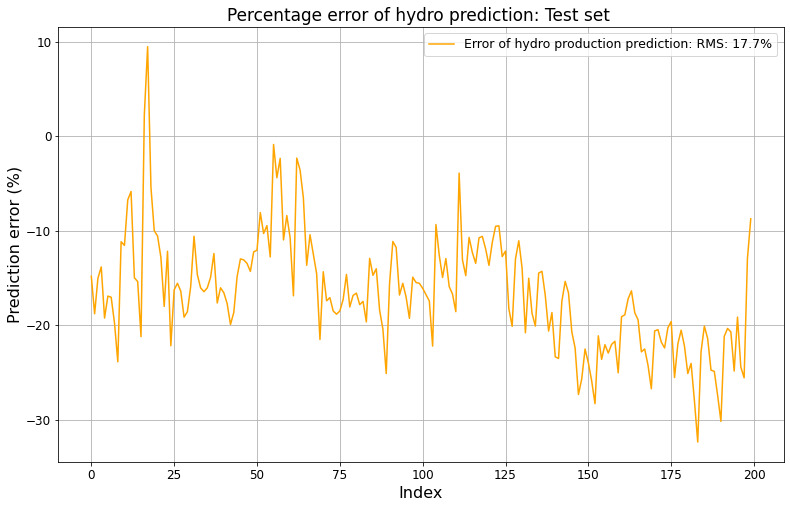

In [56]:
plt.figure(figsize=(13, 8))

bias = 27

# Mask zeros and very small values to avoid extreme divisions
epsilon = 0.01
mask = np.where(np.abs(Y_test) > epsilon)[0]
masked_Y = Y_test[mask]
masked_pred = mean_test_predictions[mask,0]


# masking also errors in predictions
mask2 = np.where(masked_pred > epsilon)[0]
masked_Y = masked_Y[mask2]
masked_pred = masked_pred[mask2]

# Limit points to plot
points_to_plot = min(200, len(masked_Y))

error_solar = (masked_pred[bias:(bias+points_to_plot)] - masked_Y[bias:(bias+points_to_plot)]) / masked_Y[bias:(bias+points_to_plot)]
error_solar_percent = error_solar * 100

# Remove inf/nan values (just in case)
error_solar_percent = np.nan_to_num(error_solar_percent, nan=0.0, posinf=0.0, neginf=0.0)

plt.plot(np.arange(points_to_plot), error_solar_percent, color='orange',
         label=f'Error of {energies[target_index]} production prediction: RMS: {round(np.sqrt(np.mean(error_solar_percent**2)), 1)}%')

plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(fr"Percentage error of {energies[target_index]} prediction: Test set ")#($\beta=1/{1./beta}, z={z}$)")
plt.grid(True)
plt.legend()

# Use lower dpi
filepath = f'4_plots/{sel_zone}/{energies[target_index]}/6.3_soloNN_error_prediction.png'
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()